# CIBUSmod example
This notebook privides a step-by-step example of how the model is run and how outputs can be visualised. The model is currently a work in progress, so this notebook will be continuosly updated as the work progresses.

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds, get_GHG
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Run test scenario 'baseline'
This test scenario includes ...
1. population increase according to World Bank projections (parameter='population'),
1. a 17% increase in milk yield per cow from 2020 to 2050 that is stronger initially and then levels off (parameter='milk_prod'),
2. an overall yield increase of 5% from 2020 to 2050 for all crops (parameter='yield'),
3. a 1% year-on-year decrease in pig meat consumption up until 2040 (parameter='consumption').

The scenario is defined in the  parameter Excel file in 'data/scenarios/baseline.xlsx'.'

### Set up scenario and modules

Set path to folders containing all default and scenario data. Select the 'baseline' scenario, define years to calculate output for and create a container to store outputs per year. To save time we use 10-year time steps, but 1-year time steps are also possible.

In [3]:
# Set paths to default and scenario data
cm.ParameterRetriever.set_data_folders(
    default = os.path.join('..','data','prod_parameters'),
    scenarios = os.path.join('..','data','scenarios'),
    relation_tables = os.path.join('..','data','relation_tables.xlsx')
)

# Define scenario, years and create output container
scn = 'food_as_industry'
years = ['2020','2030','2040','2050']
output = cm.Output()

Next, we initialise all model modules (python classes) that handle the calculations.

Each module is intialised with a **ParameterRetriever** object which reads a named parameter Excel-file from the default data folder and handles the retrieval of parameter values used in the calculations. The **ParameterRetriever** also handles updating parameter values according to a scenario.

There are three main modules that store data as attributes (generaly in the form of pandas.DataFrames). These are:

**Regions:**
<mark>W.I.P.</mark>

**DemandAndConversions:**
This module calculates demand for crop and animal production based on population, consumption of different foods, waste and conversion factors, etc. It also calculates waste and by-products generated.

**CropProduction:**
This module calculates production of crop products per unit (area) of a certain crop in a certain region.

**AnimalHerd:**
This module has subclasses for each animal species (and breed) and is initialised as one AnimalHerd object per species (e.g. cattle) + breed (e.g. dairy) + production system (e.g. conventional) + sub system (used to represent different feeding strategies, e.g. maize based) combination. The **AnimalHerd** modules calculates production of animal products per animal unit (i.e. a defining animal in the species/breed). The defining animal differs accros species/breeds with e.g. 'cows' for **CattleHerd**s, 'sows+gilts' for **PigHerd**s and 'total horses' for **HorseHerd**s.

The there are also a number of management (mgmt) modules that calculates specific aspects on the main modules. These have no data attributes but do have their own parameter Excel-files connected to them. These are:

**FeedMgmt:**
Handles the calculation of feed requirements, losses and import shares and the translation from 'feed products' to 'crop products' and 'by-products'.

**ManureMgmt:**
Handles the calculation of manure excretion and losses in stables and storage.
<mark>[Currently only nitrogen is implemented]</mark>

**PlantNutrientMgmt:**
Handles the calculation of crop fertiliser requirements and application of manure and mineral fertiliser.
<mark>[Currently calculates only plant available nitrogen requirements]</mark>

**MachineryAndEnergyMgmt:**
Handles the calculation of energy requirements in machinery, drying, greenhouses, stables etc.
<mark>[Currently only field machinery and greenhouses implemented]</mark>

Finaly the module **GeoDistributor** handles the distribution of crop and animal production across regions by solving a convex optimisation problem that minimises the deviation of crop areas and animal numbers for the current situation while meeting demand for crop and animal products as wel as a number of additional constraints.

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

### Run calculations
Now we have initialised all modules and can do the calculations. This is done by looping through the years and first updating all parameter values according to the speciefied scenario and year then (re-)calculating all classes and running the **GeoDistributor** to distribute crops and animals across regions. Finally the ouputs are stored.

In [5]:
# Loop through years
for year in years:
    print(year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(scn,year)
    
    # Get region attributes
    regions.calculate(verbose=True)
    
    # Calculate food demand
    demand.calculate(verbose=True)

    # Calculate crops
    crops.calculate(
        verbose = True
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose = True)

    # Calculate feed
    feed_mgmt.calculate(verbose=True)    

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=True)
    # Solve optimisation problem
    geodist.solve(
        verbose=True,
        solver_settings = {
            'solver':'OSQP',
            'max_iter':200000,
            'eps_abs':5e-6,
            'eps_rel':5e-6,
            'verbose':False
        }
    )
        
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=True)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=True)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=True)
    
    # Store results
    output.store(
        scn, year,
        demand, regions, crops, herds
    )

2020
[10:46:11][Regions] Getting initial crop areas and animal numbers (x0) ...
[10:46:11][Regions] Getting climate and soil attributes ...
[10:46:11][Regions] Done! Elapsed time: 0 sec
[10:46:11][DemandAndConversions] Calculating food demand ...
[10:46:12][DemandAndConversions] Calculating waste ...
[10:46:12][DemandAndConversions] Calculating crop product demand ...
[10:46:12][DemandAndConversions] Calculating animal product demand ...
[10:46:13][DemandAndConversions] Done! Elapsed time: 1 sec
[10:46:13][CropProduction] Calculating harvest ...
[10:46:13][CropProduction] Calculating production ...
[10:46:16][CropProduction] Calculating crop residues ...
[10:46:16][CropProduction] Calculating seed demand ...
[10:46:17][CropProduction] Done! Elapsed time: 5 sec
[10:46:17][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[10:46:18][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[10:46:18][AnimalHerd (cattle, beef, conv

[10:50:07][PlantNutrientMgmt] Calculating N in crop residues ...
[10:50:07][PlantNutrientMgmt] Calculating N application losses ...
[10:50:07][PlantNutrientMgmt] Calculating N soil losses ...
[10:50:08][PlantNutrientMgmt] Done! Elapsed time: 6 sec
[10:50:08][MachineryAndEnergyMgmt] Calculating energy use in field machinery ...
[10:50:11][MachineryAndEnergyMgmt] Calculating energy use for grain drying (not implemented) ...
[10:50:14][MachineryAndEnergyMgmt] Calculating energy use in greenhouses ...
[10:50:15][MachineryAndEnergyMgmt] Calculating energy use in stables (not implemented) ...
[10:50:15][MachineryAndEnergyMgmt] Calculating fuel use emissions ...
[10:50:15][MachineryAndEnergyMgmt] Done! Elapsed time: 8 sec
2030
[10:50:19][Regions] Getting initial crop areas and animal numbers (x0) ...
[10:50:19][Regions] Getting climate and soil attributes ...
[10:50:19][Regions] Done! Elapsed time: 0 sec
[10:50:19][DemandAndConversions] Calculating food demand ...
[10:50:19][DemandAndConversi

[10:51:34][GeoDistributor.solve] Done! Elapsed time: 13 sec
[10:51:34][FeedMgmt] Adjusting feed rations (not implemented) ...
[10:51:34][FeedMgmt] Calculating enteric methane emissions ...
[10:51:36][FeedMgmt] Done! Elapsed time: 2 sec
[10:51:36][ManureMgmt] Calculating VS excretion ...
[10:51:39][ManureMgmt] Calculating VS losses ...
[10:51:42][ManureMgmt] Calculating N excretion ...
[10:51:44][ManureMgmt] Calculating N losses ...
[10:52:01][ManureMgmt] Calculating N available to spread ...
[10:52:03][ManureMgmt] Done! Elapsed time: 27 sec
[10:52:03][PlantNutrientMgmt] Calculating crop N requirements ...
[10:52:05][PlantNutrientMgmt] Distributing manure ...
[10:52:08][PlantNutrientMgmt] Calculating mineral N application ...
[10:52:08][PlantNutrientMgmt] Calculating N in crop residues ...
[10:52:08][PlantNutrientMgmt] Calculating N application losses ...
[10:52:08][PlantNutrientMgmt] Calculating N soil losses ...
[10:52:09][PlantNutrientMgmt] Done! Elapsed time: 6 sec
[10:52:09][Machin

[10:53:07][GeoDistributor.make] Making constraint C1 ...
[10:53:21][GeoDistributor.make] Making constraint C2 ...
[10:53:22][GeoDistributor.make] Making constraint C3 ...
[10:53:22][GeoDistributor.make] Making constraint C4 ...
[10:53:22][GeoDistributor.make] Making constraint C5 ...
[10:53:22][GeoDistributor.make] Making constraint C6 ...
[10:53:23][GeoDistributor.make] Making constraint C7 ...
[10:53:24][GeoDistributor.make] Defining problem ...
[10:53:24][GeoDistributor.make] Done! Elapsed time: 18 sec
[10:53:24][GeoDistributor.solve] Finding solution ...
[10:53:56][GeoDistributor.solve] Optimal solution found! Status: 'optimal', Itterations: 27650, Solver: 'OSQP'
[10:53:56][GeoDistributor.solve] Applying solution
[10:53:58][GeoDistributor.solve] Done! Elapsed time: 34 sec
[10:53:58][FeedMgmt] Adjusting feed rations (not implemented) ...
[10:53:58][FeedMgmt] Calculating enteric methane emissions ...
[10:54:01][FeedMgmt] Done! Elapsed time: 2 sec
[10:54:01][ManureMgmt] Calculating VS

[10:55:08][FeedMgmt] Calculating feed losses ...
[10:55:19][FeedMgmt] Calculating demand for crop products ...
[10:55:26][FeedMgmt] Calculating demand for by-products ...
[10:55:32][FeedMgmt] Done! Elapsed time: 37 sec
[10:55:32][GeoDistributor.make] Getting x0 and making indexes ...
[10:55:32][GeoDistributor.make] Creating demand vector ...
[10:55:32][GeoDistributor.make] Scaling ...
[10:55:32][GeoDistributor.make] Making objective O1 ...
[10:55:32][GeoDistributor.make] Making constraint C1 ...
[10:55:46][GeoDistributor.make] Making constraint C2 ...
[10:55:47][GeoDistributor.make] Making constraint C3 ...
[10:55:47][GeoDistributor.make] Making constraint C4 ...
[10:55:47][GeoDistributor.make] Making constraint C5 ...
[10:55:47][GeoDistributor.make] Making constraint C6 ...
[10:55:48][GeoDistributor.make] Making constraint C7 ...
[10:55:49][GeoDistributor.make] Defining problem ...
[10:55:49][GeoDistributor.make] Done! Elapsed time: 17 sec
[10:55:49][GeoDistributor.solve] Finding solu

## Save results to file
We can write results to a binary file using pickle for future use.

In [6]:
# Write file
output.save_file('out_'+scn+'.pkl')

In [4]:
# Read file
output = cm.Output.from_file('out_'+scn+'.pkl')

## Plot output
Here are some example output plots.

In [5]:
# Common style for bar plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey'
}

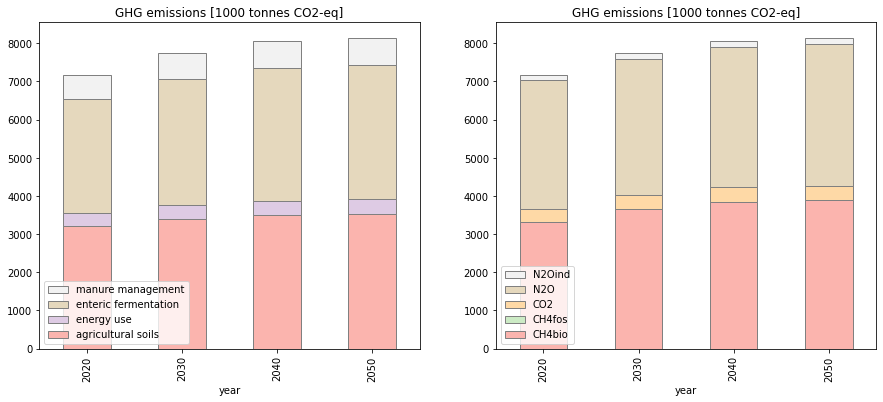

In [6]:
plot_data = get_GHG(output).sum()/1000000

fig, axs = plt.subplots(1,2, figsize=(15,6))

ax=axs[0]
(
    plot_data
    .groupby(['year','process'])
    .sum()
    .unstack()
).plot.bar(stacked=True, ax=ax, **bar_style)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')   
ax.set_title('GHG emissions [1000 tonnes CO2-eq]')

ax=axs[1]
(
    plot_data
    .groupby(['year','compound'])
    .sum()
    .unstack()
).plot.bar(stacked=True, ax=ax, **bar_style)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')   
ax.set_title('GHG emissions [1000 tonnes CO2-eq]')

plt.show()

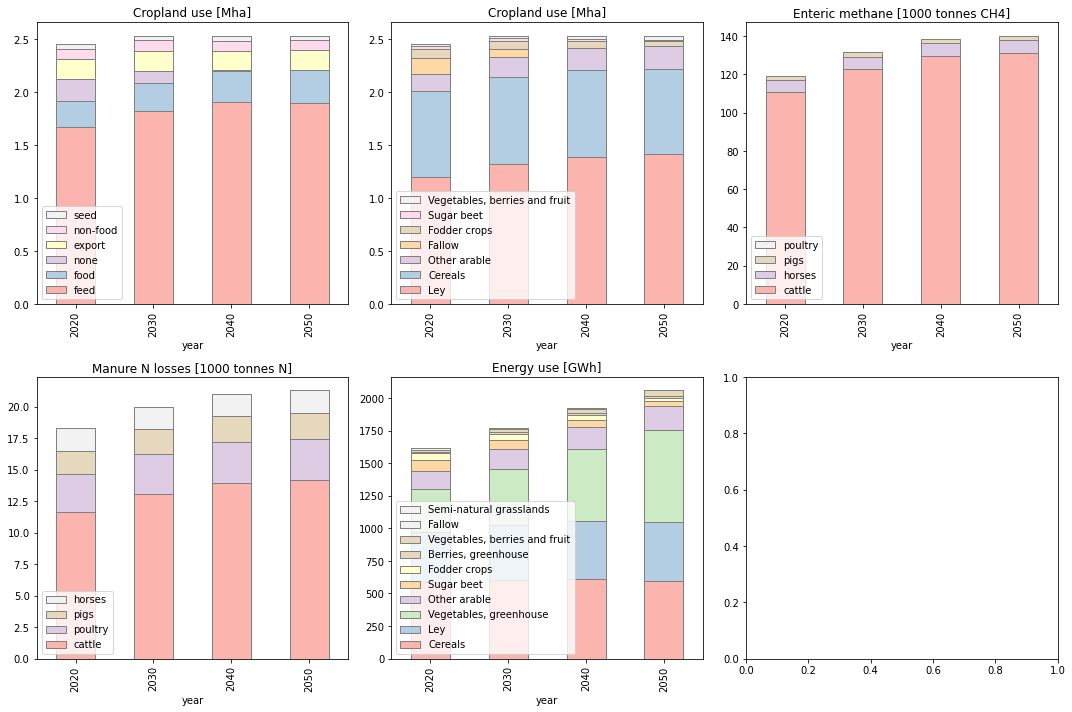

In [35]:
# crop --> crop_group
cg_rel = pd.Series(cm.ParameterRetriever.get_rel('crop','crop_group')).rename('crop_group').rename_axis('crop')
# crop --> land_use
lu_rel = pd.Series(cm.ParameterRetriever.get_rel('crop','land_use')).rename('land_use').rename_axis('crop')

# broader crop categories
cg_rel = cg_rel.replace({
    'Cereals, winter':'Cereals',
    'Cereals, spring':'Cereals',
    'Grain legumes':'Other arable',
    'Brassicaceae':'Other arable',
    'Potatoes':'Other arable',
    'Beets':'Other arable',
    'Energy crops':'Other arable',
    'Green manure':'Other arable',
    'Vegetables':'Vegetables, berries and fruit',
    'Berries':'Vegetables, berries and fruit',
    'Fruit trees':'Vegetables, berries and fruit',
})

idx = pd.IndexSlice

fig, axs = plt.subplots(2,3, figsize=(15,10))

# Cropland use --->
ax = axs[0,0]
n_col = len(output.loc[(scn,'2020'),'crp'].production_per_use.columns)
plot_data = pd.concat([
    (
        output.loc[(scn,y),'crp'].production_per_use
        .transform(lambda x: x/x.sum() if x.sum()>0 else [0]*(n_col-1)+[1], axis=1)
        .mul(
            output.loc[(scn,y),'crp'].area,
            axis=0
        )
        .join(lu_rel)
        .set_index('land_use', append=True)
        .rename_axis('demand', axis=1)
        .loc[idx[:,:,:,'cropland'],:]
        .sum()
    )
    for y in years
], axis=1).T / 1000000
plot_data.index = pd.Index(years,name='year')

plot_data.columns = plot_data.columns.str.replace(r'(feed).*','feed',regex=True)
plot_data = plot_data.groupby('demand', axis=1).sum()

(
    plot_data.sort_values(axis=1, by='2020', ascending=False).reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, **bar_style)
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')   
ax.set_title('Cropland use [Mha]')

# Cropland use --->
ax = axs[0,1]
plot_data = pd.concat([
    (
        output.loc[(scn,y),'crp'].area.rename('area')
        .to_frame().join(cg_rel).join(lu_rel)
        .set_index('land_use', append=True)
        .loc[idx[:,:,:,'cropland']]
        .groupby('crop_group').sum()['area']
    )
    for y in years
], axis=1).T / 1000000
plot_data.index = pd.Index(years,name='year')
(
    plot_data.sort_values(axis=1, by='2020', ascending=False).reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, **bar_style)
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')
ax.set_title('Cropland use [Mha]')

# Enteric methane --->
ax = axs[0,2]
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].enteric_methane.groupby(['species'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T / 1000000
plot_data.index = pd.Index(years,name='year')

(
    plot_data.sort_values(axis=1, by='2020', ascending=False).reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, **bar_style)
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')
ax.set_title('Enteric methane [1000 tonnes CH4]')

# N losses --->
ax = axs[1,0]
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].manure.N_loss.groupby(['species'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T / 1000000
plot_data.index = pd.Index(years,name='year')



(
    plot_data.sort_values(axis=1, by='2020', ascending=False).reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, **bar_style)
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')   
ax.set_title('Manure N losses [1000 tonnes N]')

# Energy use --->
ax = axs[1,1]

plot_data = pd.concat(
    [
        output.loc[(scn,y),'crp'].energy_use
        .rename(cg_rel)
        .sum(axis=1)
        .groupby('crop').sum()
        for y in years
    ],
    axis=1
    
).T * 1e-6
plot_data.index = pd.Index(years,name='year')

(
    plot_data.sort_values(axis=1, by='2020', ascending=False).reset_index()
    .plot.bar(x='year', ax = ax, stacked=True, **bar_style)
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower left')   
ax.set_title('Energy use [GWh]')

fig.tight_layout()
plt.show()

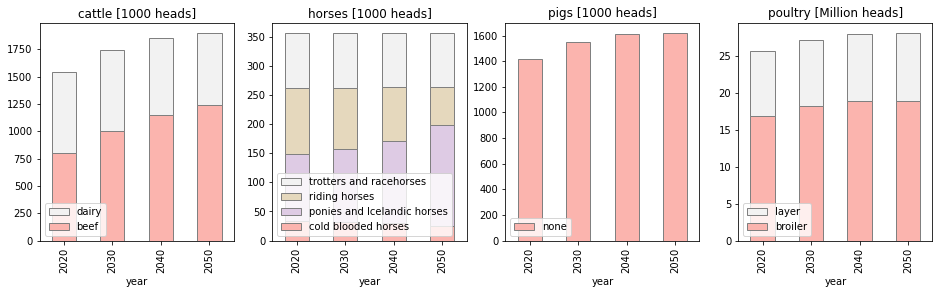

In [36]:
# Number of animal heads
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].heads.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

idxs = plot_data.columns.droplevel('breed').unique()

fig, axs = plt.subplots(1,4, figsize=(16,4))

n=0
for idx in idxs:
    
    ax=axs[n]
    
    (
        (plot_data / (1000000 if idx=='poultry' else 1000))
        .xs(idx,level='species',axis=1).
        reset_index().plot.bar(x='year', ax = ax, stacked=True, **bar_style)
    )
    
    ax.set_title(idx + (' [Million heads]' if idx=='poultry' else ' [1000 heads]'))
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='lower left')
    n += 1
        
plt.show()

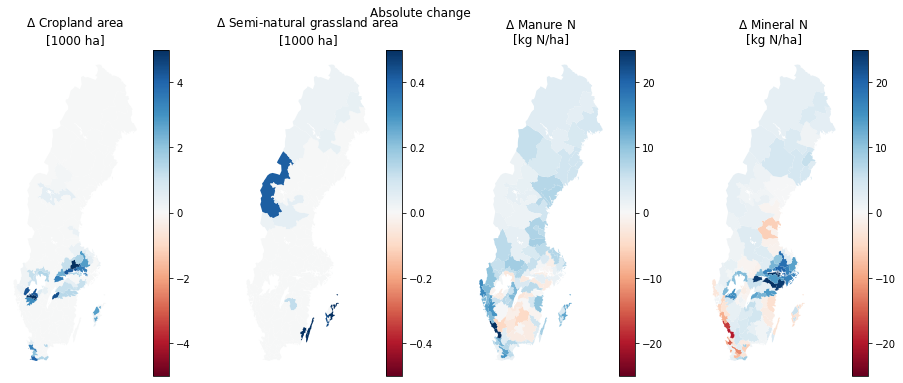

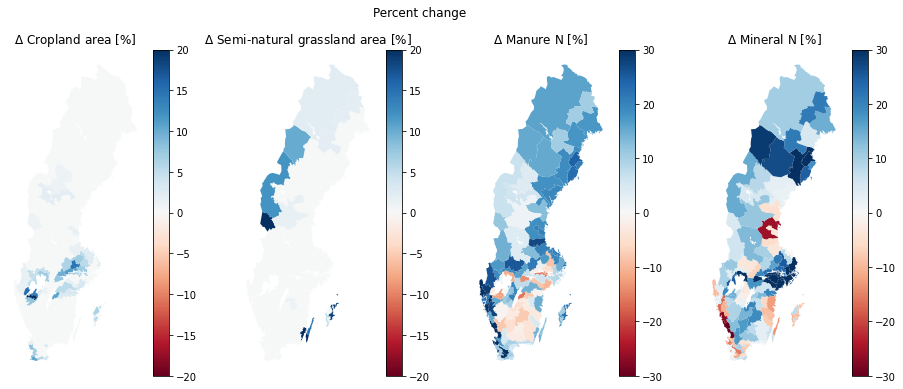

In [37]:
rel = cm.ParameterRetriever.get_rel('crop','land_use')
area = (
    pd.concat([output.loc[(scn,y),'crp'].area for y in ['2020','2050']],axis=1)
    .rename(columns={0:'2020',1:'2050'})
    .rename(rel).loc['cropland']
    .groupby('region')
    .sum()
)

# ABSOLUTE

idx = pd.IndexSlice
fig, axs = plt.subplots(1,4, figsize=(16,6))

# Cropland area --->
ax = axs[0]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .area.rename(rel).loc['cropland']
     .groupby('region').sum()/1000)
    -
    (output.loc[(scn,'2020'),'crp']
     .area.rename(rel).loc['cropland']
     .groupby('region').sum()/1000),
     cmap='RdBu',
     vmin=-5,
     vmax=5,
     ax=ax
)
ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
ax.set_axis_off()

# Grassland area --->
ax = axs[1]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .area.rename(rel).loc['semi-natural grasslands']
     .groupby('region').sum()/1000)
    -
    (output.loc[(scn,'2020'),'crp']
     .area.rename(rel).loc['semi-natural grasslands']
     .groupby('region').sum()/1000),
     cmap='RdBu',
     vmin=-0.5,
     vmax=0.5,
     ax=ax
)
ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
ax.set_axis_off()

# Manure N application --->
ax = axs[2]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
    .fertiliser.manure_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()/area['2050']
     -
    output.loc[(scn,'2020'),'crp']
    .fertiliser.manure_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()/area['2020']),
     cmap='RdBu',
     vmin=-25,
     vmax=25,
     ax=ax
)
ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
ax.set_axis_off()

# Mineral N application --->
ax = axs[3]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .fertiliser.mineral_N.sum(axis=1)
     .groupby('region').sum()/area['2050']
     -
    output.loc[(scn,'2020'),'crp']
     .fertiliser.mineral_N.sum(axis=1)
     .groupby('region').sum()/area['2020']),
     cmap='RdBu',
     vmin=-25,
     vmax=25,
     ax=ax
)
ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
ax.set_axis_off()



plt.suptitle('Absolute change')
plt.show()

# PERCENT

idx = pd.IndexSlice
fig, axs = plt.subplots(1,4, figsize=(16,6))

# Cropland area --->
ax = axs[0]
plot.map_from_series(
    ((output.loc[(scn,'2050'),'crp']
     .area.rename(rel).loc['cropland']
     .groupby('region').sum()/1000)
    -
    (output.loc[(scn,'2020'),'crp']
     .area.rename(rel).loc['cropland']
     .groupby('region').sum()/1000))
    /
    (output.loc[(scn,'2020'),'crp']
     .area.rename(rel).loc['cropland']
     .groupby('region').sum()/1000)*100,
     cmap='RdBu',
     vmin=-20,
     vmax=20,
     ax=ax
)
ax.set_title('$\Delta$ Cropland area [%]')
ax.set_axis_off()

# Grassland area --->
ax = axs[1]
plot.map_from_series(
    ((output.loc[(scn,'2050'),'crp']
     .area.rename(rel).loc['semi-natural grasslands']
     .groupby('region').sum()/1000)
    -
    (output.loc[(scn,'2020'),'crp']
     .area.rename(rel).loc['semi-natural grasslands']
     .groupby('region').sum()/1000))
    /
    (output.loc[(scn,'2020'),'crp']
     .area.rename(rel).loc['semi-natural grasslands']
     .groupby('region').sum()/1000)*100,
     cmap='RdBu',
     vmin=-20,
     vmax=20,
     ax=ax
)
ax.set_title('$\Delta$ Semi-natural grassland area [%]')
ax.set_axis_off()

# Manure N application --->
ax = axs[2]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .fertiliser.manure_N.sum(axis=1)
     .groupby('region').sum()/area['2050']
     -
    output.loc[(scn,'2020'),'crp']
     .fertiliser.manure_N.sum(axis=1)
     .groupby('region').sum()/area['2020'])
    /
    (output.loc[(scn,'2020'),'crp']
     .fertiliser.manure_N.sum(axis=1)
     .groupby('region').sum()/area['2020'])*100,
     cmap='RdBu',
     vmin=-30,
     vmax=30,
     ax=ax
)
ax.set_title('$\Delta$ Manure N [%]')
ax.set_axis_off()

# Mineral N application --->
ax = axs[3]
plot.map_from_series(
    (output.loc[(scn,'2050'),'crp']
     .fertiliser.mineral_N.sum(axis=1)
     .groupby('region').sum()/area['2050']
     -
    output.loc[(scn,'2020'),'crp']
     .fertiliser.mineral_N.sum(axis=1)
     .groupby('region').sum()/area['2020'])
    /
    (output.loc[(scn,'2020'),'crp']
     .fertiliser.mineral_N.sum(axis=1)
     .groupby('region').sum()/area['2020'])*100,
     cmap='RdBu',
     vmin=-30,
     vmax=30,
     ax=ax
)
ax.set_title('$\Delta$ Mineral N [%]')
ax.set_axis_off()

plt.suptitle('Percent change')
plt.show()

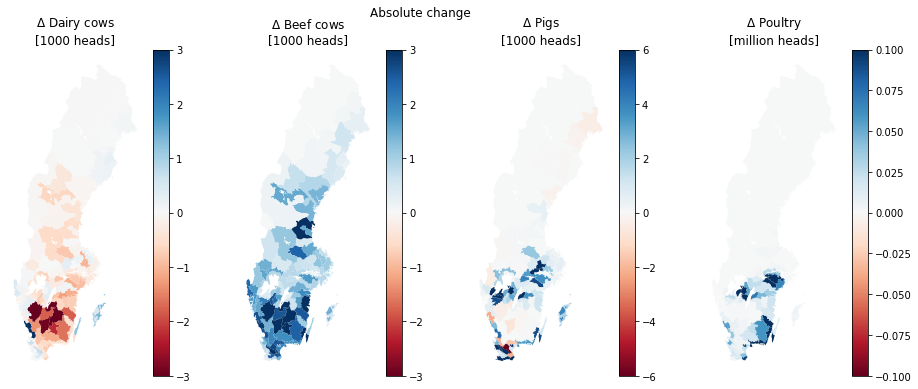

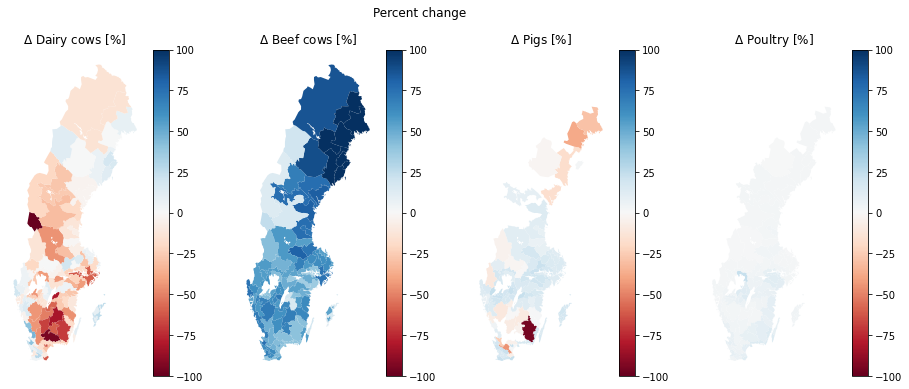

In [40]:
# ABSOLUTE

fig, axs = plt.subplots(1,4, figsize=(16,6))

# Dairy cows --->
ax = axs[0]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000),
     cmap='RdBu',
     vmin=-3,
     vmax=3,
     ax=ax
)
ax.set_title('$\Delta$ Dairy cows\n[1000 heads]')
ax.set_axis_off()

# Beef cows --->
ax = axs[1]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)/1000),
     cmap='RdBu',
     vmin=-3,
     vmax=3,
     ax=ax
)
ax.set_title('$\Delta$ Beef cows\n[1000 heads]')
ax.set_axis_off()

# Pigs --->
ax = axs[2]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1)/1000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1)/1000),
     cmap='RdBu',
     vmin=-6,
     vmax=6,
     ax=ax
)
ax.set_title('$\Delta$ Pigs\n[1000 heads]')
ax.set_axis_off()

# Poultry --->
ax = axs[3]
plot.map_from_series(
    (output.loc[(scn,'2050'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1)/1000000)
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1)/1000000),
     cmap='RdBu',
     vmin=-0.1,
     vmax=0.1,
     ax=ax
)
ax.set_title('$\Delta$ Poultry\n[million heads]')
ax.set_axis_off()

plt.suptitle('Absolute change')
plt.show()

# PERCENT

fig, axs = plt.subplots(1,4, figsize=(16,6))

# Dairy cows --->
ax = axs[0]
plot.map_from_series(
    ((output.loc[(scn,'2050'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1))
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)))
    /
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('dairy','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1))*100,
     cmap='RdBu',
     vmin=-100,
     vmax=100,
     ax=ax
)
ax.set_title('$\Delta$ Dairy cows [%]')
ax.set_axis_off()

# Beef cows --->
ax = axs[1]
plot.map_from_series(
    ((output.loc[(scn,'2050'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1))
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1)))
    /
    (output.loc[(scn,'2020'),'ani']
     .heads.xs(('beef','cows'),level=('breed','animal'), axis=1)
     .sum(axis=1))*100,
     cmap='RdBu',
     vmin=-100,
     vmax=100,
     ax=ax
)
ax.set_title('$\Delta$ Beef cows [%]')
ax.set_axis_off()

# Pigs --->
ax = axs[2]
plot.map_from_series(
    ((output.loc[(scn,'2050'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1))
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1)))
    /
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('pigs',level='species', axis=1)
     .sum(axis=1))*100,
     cmap='RdBu',
     vmin=-100,
     vmax=100,
     ax=ax
)
ax.set_title('$\Delta$ Pigs [%]')
ax.set_axis_off()

# Poultry --->
ax = axs[3]
plot.map_from_series(
    ((output.loc[(scn,'2050'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1))
    -
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1)))
    /
    (output.loc[(scn,'2020'),'ani']
     .heads.xs('poultry',level='species', axis=1)
     .sum(axis=1))*100,
     cmap='RdBu',
     vmin=-100,
     vmax=100,
     ax=ax
)
ax.set_title('$\Delta$ Poultry [%]')
ax.set_axis_off()

plt.suptitle('Percent change')
plt.show()

In [ ]:
# Harvest and areas --> ICBM

pd.concat([
    pd.concat([
        pd.concat({y: output.loc[(scn,y),'crp'].area.rename('area')}, names=['year']),
        pd.concat({y: output.loc[(scn,y),'crp'].harvest.rename('harvest')}, names=['year'])
    ], axis=1)
for y in years]).to_clipboard()